# Analiza Eksploracyjna Danych (EDA) dla eksperymentu SSVEP
Notatnik ma na celu wczytanie danych zebranych z urządzenia EEG zapisanych w formacie `.fif` i przeprowadzenie podstawowej analizy częstotliwościowej sygnału (FFT, PSD) w tym porównanie sygnału surowego oraz sygnału po zaaplikowaniu filtru Savitzky-Golay.

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, welch
from scipy.fft import fft, fftfreq
import os
import sys
import mne 

sys.path.append(os.path.abspath('../experiment'))

from src.config.bci_config import SAMPLING_RATE, TARGET_CHANNELS, SG_WINDOW, SG_POLYORDER, WINDOW_TIME_FRAME

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Wczytanie danych .fif z eksperymentu
Używamy pakietu `mne`, do załadowania zapisanego wcześniej pliku `.fif`.

In [208]:
filename = 'kacper/kacper2.fif'

# zmień do analizy konkretnego markera, np. "15" dla 15 Hz
target_marker_freq = "10"

try:
    raw = mne.io.read_raw_fif(filename, preload=True)
    raw = raw.load_data()
    raw = raw.pick_types(eeg=True, stim=False, eog=False, exclude="bads")
    raw.apply_function(lambda x: x * 10 ** -6)
    raw.filter(l_freq=4, h_freq=45)
    #raw.notch_filter(freqs=[6, 7.5, 8.57, 10, 12, 15], method='spectrum_fit', filter_length='auto', phase='zero')
    
    events, event_dict = mne.events_from_annotations(raw)
    print("Dostępne markery w nagraniu:", event_dict)
    
    target_event_id = None
    target_event_name = None
    for marker_name, marker_id in event_dict.items():
        if f"TARGET_{target_marker_freq}" in marker_name:
            target_event_id = marker_id
            target_event_name = marker_name
            print(f"Wybrano marker: {marker_name} (ID: {marker_id})")
            break
            
    if target_event_id is not None:
        epochs = mne.Epochs(raw, events, event_id=target_event_id, tmin=0.0, tmax=WINDOW_TIME_FRAME, baseline=None, preload=True)
        
        target_epoch_data = epochs.get_data()[0]
        print(f"Wyizolowano epoch o wymiarach: {target_epoch_data.shape}")
        
        data = target_epoch_data
        num_samples = data.shape[1]
        time = epochs.times
    else:
        print(f"Nie odnaleziono markera dla bodźca: {target_marker_freq} Hz w pliku!")
        data = raw.get_data()
        num_samples = data.shape[1]
        time = np.arange(num_samples) / SAMPLING_RATE
        
except FileNotFoundError:
    print(f"Nie można znaleźć pliku '{filename}'.")
    # Awaryjne wygenerowanie dummy-danych
    tmax = WINDOW_TIME_FRAME
    time = np.linspace(0, tmax, int(tmax * SAMPLING_RATE), endpoint=False)
    data = np.random.randn(16, len(time)) + 5 * np.sin(2 * np.pi * float(target_marker_freq) * time)
    num_samples = data.shape[1]

# Skupiamy się na pierwszym kanale z wyznaczonych w TARGET_CHANNELS
ch_idx = TARGET_CHANNELS[1]
raw_signal = data[ch_idx, :]
print(f"Analizujemy kanał nr {ch_idx}")

Dostępne markery w nagraniu: {np.str_('START-PHASE-OFFLINE'): 1, np.str_('STOP-PHASE-OFFLINE'): 2, np.str_('TARGET_10_Q R S T U V W X Y Z + - * / ( )'): 3, np.str_('TARGET_12_1 2 3 4 5 6 7 8 9 0'): 4, np.str_('TARGET_15_$ & @ " . , ? ! % : ; = ~ # Del Blank'): 5, np.str_('TARGET_6_UNDO'): 6, np.str_('TARGET_7.5_START'): 7, np.str_('TARGET_8.57_A B C D E F G H I J K L M N O P'): 8}
Wybrano marker: TARGET_10_Q R S T U V W X Y Z + - * / ( ) (ID: 3)
Wyizolowano epoch o wymiarach: (16, 1251)
Analizujemy kanał nr 6


## 2. Porównanie sygnału surowego względem Savitzky-Golay (Filtrowanego)
Wyciągamy średnią ze wszystkich kanałów (CAR) na surowym sygnale, a następnie aplikujemy interesujący nas filtr `savgol_filter`.

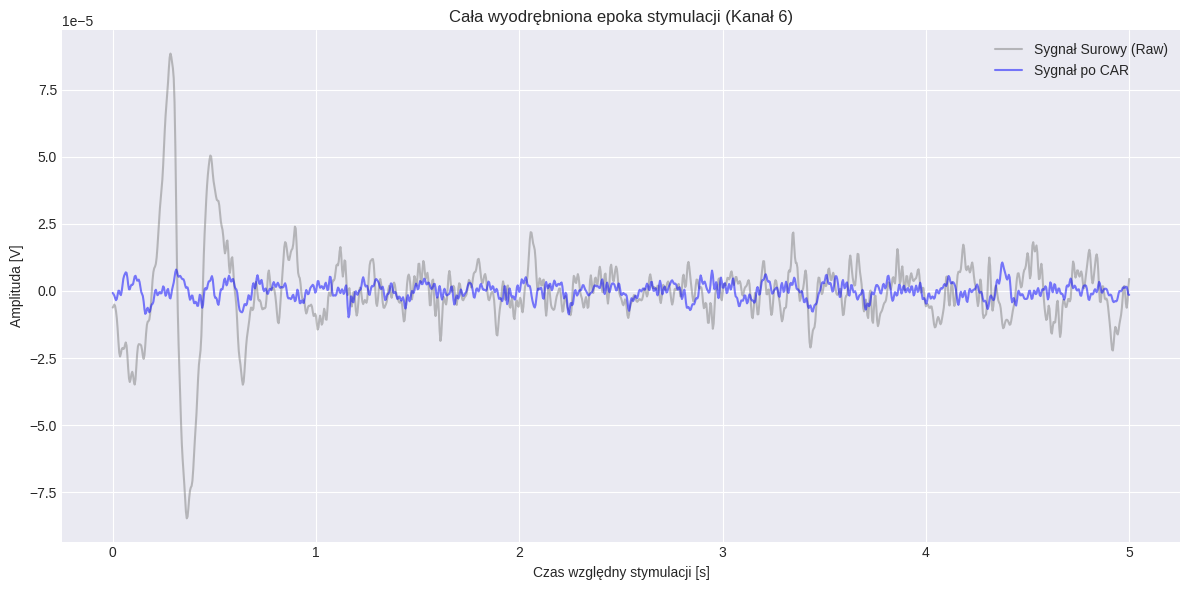

In [209]:
# Operacja Common Average Reference (CAR)
mean_signal = np.mean(data[TARGET_CHANNELS, :], axis=0)
car_signal = raw_signal - mean_signal

# Nakładanie filtra Savitzky-Golay na wyciętą epokę
#filtered_signal = savgol_filter(car_signal, window_length=15, polyorder=SG_POLYORDER)

# Renderowanie wykresów dziedziny czasu dla całej epoki docelowej
plt.figure(figsize=(12, 6))

plt.plot(time, raw_signal, label="Sygnał Surowy (Raw)", alpha=0.5, color='gray')
plt.plot(time, car_signal, label="Sygnał po CAR", alpha=0.5, color='blue')
#plt.plot(time, filtered_signal, label=f"SG Filter (win={SG_WINDOW}, order={SG_POLYORDER})", linewidth=1.5, color='red')

plt.title(f"Cała wyodrębniona epoka stymulacji (Kanał {ch_idx})")
plt.xlabel("Czas względny stymulacji [s]")
plt.ylabel("Amplituda [V]") 
plt.legend()
plt.tight_layout()
plt.show()

## 3. Analiza Częstotliwości za pomocą Szybkiej Transformaty Fouriera (FFT)
Obliczamy widmo amplitudowe za pomocą FFT i rysujemy wynik w przedziale do 40 Hz (optymalne pasmo w badaniach SSVEP).

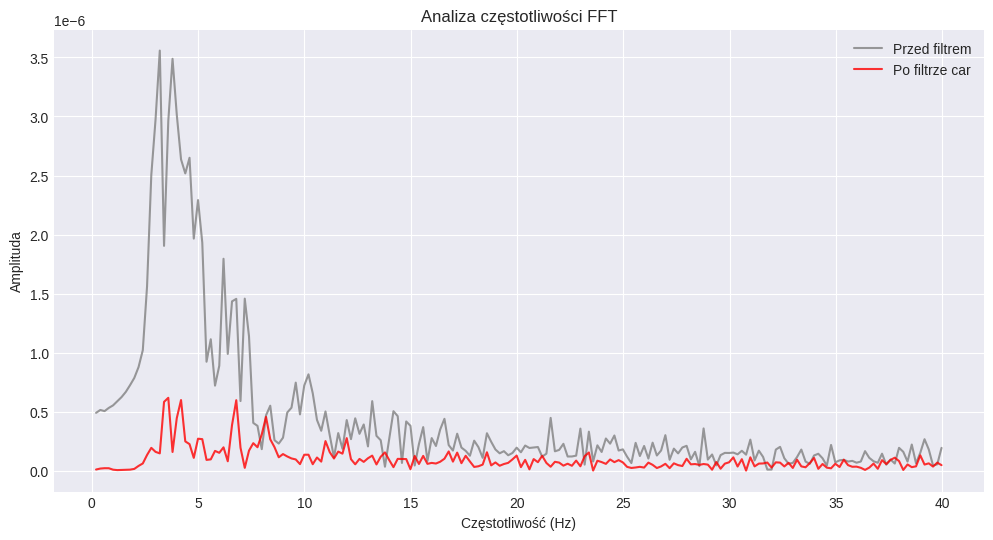

In [210]:
def plot_fft(signal, title, color):
    # Obliczanie widma amplitudowego
    N = len(signal)
    signal_fft = fft(signal)
    freqs = fftfreq(N, 1 / SAMPLING_RATE)

    # Bierzemy pod uwagę tylko częstotliwości dodatnie
    pos_mask = freqs > 0
    freqs = freqs[pos_mask]
    amplitudes = np.abs(signal_fft[pos_mask]) / N

    # Zawężanie widma do SSVEP
    mask_ssvep = freqs <= 40

    plt.plot(freqs[mask_ssvep], amplitudes[mask_ssvep], label=title, color=color, alpha=0.8)

plt.figure(figsize=(12, 6))
plot_fft(raw_signal, "Przed filtrem", 'gray')
plot_fft(car_signal, "Po filtrze car", 'red')

plt.title("Analiza częstotliwości FFT")
plt.xlabel("Częstotliwość (Hz)")
plt.ylabel("Amplituda")
plt.legend()
plt.show()

## 4. Wykres Gęstości Widmowej Mocy (Power Spectral Density - PSD)
Porównanie sygnału surowego oraz przefiltrowanego za pomocą metody Welcha.

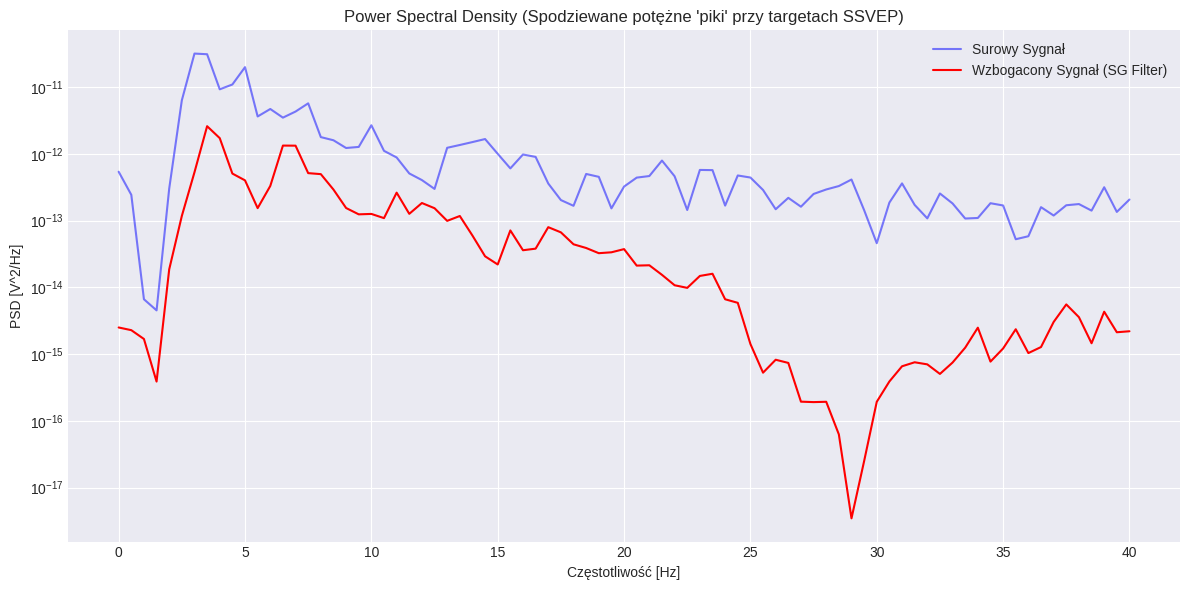

In [ ]:
# Szacowna długość fragmentu dla Welcha ustalamy np. na 2 sekundy stąd nperseg = 2 * SAMPLING_RATE
nperseg = min(2 * SAMPLING_RATE, len(raw_signal))

# Obliczanie Welcha dla obydwu sygnałów
f_raw, psd_raw = welch(raw_signal, fs=SAMPLING_RATE, nperseg=nperseg)
f_filt, psd_filt = welch(car_signal, fs=SAMPLING_RATE, nperseg=nperseg)

# Widmo SSVEP max 40 Hz
plot_range_raw = f_raw <= 40
plot_range_filt = f_filt <= 40

plt.figure(figsize=(12, 6))
plt.semilogy(f_raw[plot_range_raw], psd_raw[plot_range_raw], label="Surowy Sygnał", color='blue', alpha=0.5)
plt.semilogy(f_filt[plot_range_filt], psd_filt[plot_range_filt], label=f"Wzbogacony Sygnał (SG Filter)", color='red', linewidth=1.5)

plt.title("Power Spectral Density (Spodziewane potężne 'piki' przy targetach SSVEP)")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("PSD [V^2/Hz]")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Klasyfikacja przy użyciu Canonical Correlation Analysis (CCA)
Skrypt symuluje, w jaki sposób Twój klasyfikator `CCAPredictor` w aplikacji przetwarza wycięte okno sygnału i podejmuje decyzję o tym, do jakiej częstotliwości należy pobudzenie.
CCA poszukuje maksymalnej korelacji między odczytami EEG, a matematycznie wygenerowanymi referencyjnymi sygnałami sinus/cosinus (w tym z ich wybranymi harmonikami).

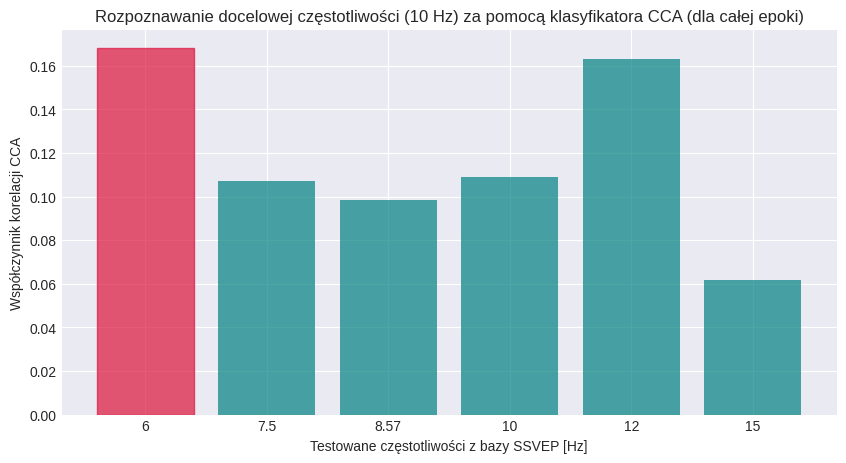

In [212]:
from sklearn.cross_decomposition import CCA
from src.config.bci_config import FREQS, SAMPLES_PER_WINDOW

def generate_reference_signals(length, freq, sampling_rate, num_harmonics=2):
    t = np.arange(length) / sampling_rate
    y = []
    for i in range(1, num_harmonics + 1):
        y.append(np.sin(2 * np.pi * i * freq * t))
        y.append(np.cos(2 * np.pi * i * freq * t))
    return np.array(y).T

current_window_samples = num_samples

car_all_channels = data - np.mean(data[TARGET_CHANNELS, :], axis=0) # CAR na wszystkich kanałach
X_target_channels = car_all_channels[TARGET_CHANNELS, :] # (kanały, próbki)
#filtered_all = savgol_filter(X_target_channels, window_length=SG_WINDOW, polyorder=SG_POLYORDER, axis=1)

epoch_X = X_target_channels.T

cca = CCA(n_components=1)
correlations = {}

for freq in FREQS:
    Y_ref = generate_reference_signals(current_window_samples, freq, SAMPLING_RATE, num_harmonics=2)
    
    # Trenujemy i transformujemy model CCA
    cca.fit(epoch_X, Y_ref)
    Xc, Yc = cca.transform(epoch_X, Y_ref)
    
    # Obliczamy współczynnik korelacji
    corr = np.corrcoef(Xc[:, 0], Yc[:, 0])[0, 1]
    correlations[freq] = corr

freqs_list = list(correlations.keys())
corr_values = list(correlations.values())

plt.figure(figsize=(10, 5))
bars = plt.bar([str(f) for f in freqs_list], corr_values, color='teal', alpha=0.7)

# Najwyższa korelacja na czerwono na wykresie
best_idx = np.argmax(corr_values)
bars[best_idx].set_color('crimson')

plt.title(f"Rozpoznawanie docelowej częstotliwości ({target_marker_freq} Hz) za pomocą klasyfikatora CCA (dla całej epoki)")
plt.xlabel("Testowane częstotliwości z bazy SSVEP [Hz]")
plt.ylabel("Współczynnik korelacji CCA")
plt.show()